# Cholesky decomposition

For symmetric positive definite (SPD) $A$:

$A = LL^T$ (e.g. least-seq)

| Property | LU | Cholesky |
|---|---|---|
| Applies to | any invertible | symmetric +ve def only |
| Pivoting | required | not needed |
| Output | $P, L, U$ (3 matrices) | $L$ (1 matrix) |
| Cost | $\frac{2}{3}n^3$ | $\frac{1}{3}n^3$ (half LU) |
| Stability | needs pivoting | always stable |

Half the cost, no pivoting, one output. The catch: $A$ must be symmetric postitive definite (SPD):

- Symmetric: $A = A^T$
- Positive definite: $x^T A x > 0$ for all $x \neq 0$
- Equivalently: all eigenvalues > 0
- Common: $A^T A$ is always SPD (if $A$ has full column rank)

In [1]:
import os
import sys

if "COLAB_GPU" in os.environ:
    os.system("git clone https://github.com/PritRaj1/tensor_inv.git 2>/dev/null")
    sys.path.insert(0, "/content/tensor_inv/src")
else:
    src = "src" if os.path.isdir("src") else "../src"
    sys.path.insert(0, src)

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

## Step by step

$A = LL^T$ 

Column $j$ of $L$:

1. Diagonal: $L_{jj} = \sqrt{A_{jj} - \sum_{k<j} L_{jk}^2}$
2. Below diagonal: $L_{ij} = \frac{1}{L_{jj}} \left( A_{ij} - \sum_{k<j} L_{ik} L_{jk} \right)$ for $i > j$

Ops needed per column:
- 1 sqrt (diagonal only)
- $n - j$ divides (sub-diagonal)
- dot products (the sums above) = multiply + add

The dot products dominate at large $n$.

In [ ]:
def cholesky_unblocked(A):
    """Reference implementation."""
    n = A.shape[0]
    L = torch.zeros_like(A)
    for j in range(n):
        L[j, j] = torch.sqrt(A[j, j] - L[j, :j] @ L[j, :j])
        for i in range(j + 1, n):
            L[i, j] = (A[i, j] - L[i, :j] @ L[j, :j]) / L[j, j]
    return L

In [3]:
A = torch.tensor(
    [[4.0, 2.0, 1.0], [2.0, 5.0, 3.0], [1.0, 3.0, 6.0]], dtype=torch.float64
)
print(f"A =\n{A}")
print(f"symmetric: {(A == A.T).all().item()}")
print(f"eigenvalues: {torch.linalg.eigvalsh(A).tolist()}")
print("all positive -> SPD")

n = 3
L = torch.zeros(n, n, dtype=torch.float64)

for j in range(n):
    # diagonal: sqrt of A[j,j] minus sum of squares
    L[j, j] = torch.sqrt(A[j, j] - L[j, :j] @ L[j, :j])
    print(
        f"\ncol {j}: L[{j},{j}] = sqrt({A[j, j]:.0f} - {(L[j, :j] @ L[j, :j]).item():.1f}) = {L[j, j]:.4f}"
    )

    # sub-diagonal: scale by 1/L[j,j]
    for i in range(j + 1, n):
        L[i, j] = (A[i, j] - L[i, :j] @ L[j, :j]) / L[j, j]
        print(
            f"       L[{i},{j}] = ({A[i, j]:.0f} - {(L[i, :j] @ L[j, :j]).item():.1f}) / {L[j, j]:.4f} = {L[i, j]:.4f}"
        )

print(f"\nL =\n{L}")
print(f"\n||LL^T - A|| = {(L @ L.T - A).abs().max():.1e}")

A =
tensor([[4., 2., 1.],
        [2., 5., 3.],
        [1., 3., 6.]], dtype=torch.float64)
symmetric: True
eigenvalues: [1.9213469419616895, 3.730159123688258, 9.348493934350051]
all positive -> SPD

col 0: L[0,0] = sqrt(4 - 0.0) = 2.0000
       L[1,0] = (2 - 0.0) / 2.0000 = 1.0000
       L[2,0] = (1 - 0.0) / 2.0000 = 0.5000

col 1: L[1,1] = sqrt(5 - 1.0) = 2.0000
       L[2,1] = (3 - 0.5) / 2.0000 = 1.2500

col 2: L[2,2] = sqrt(6 - 1.8) = 2.0463

L =
tensor([[2.0000, 0.0000, 0.0000],
        [1.0000, 2.0000, 0.0000],
        [0.5000, 1.2500, 2.0463]], dtype=torch.float64)

||LL^T - A|| = 0.0e+00


## Solving $Ax = b$

Same as LU but simpler ($L$ and $L^T$ instead of separate $L, U$):
1. Forward sub: $Ly = b$
2. Backward sub: $L^T x = y$

In [4]:
b = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float64)

# forward sub: Ly = b
y = torch.linalg.solve_triangular(L, b.unsqueeze(1), upper=False).squeeze()

# backward sub: L^T x = y
x = torch.linalg.solve_triangular(L.T, y.unsqueeze(1), upper=True).squeeze()

print(f"x = {x.tolist()}")
print(f"residual ||Ax - b|| = {(A @ x - b).norm():.1e}")

x = [0.08955223880597014, 0.10447761194029856, 0.4328358208955223]
residual ||Ax - b|| = 4.4e-16


## Blocked Cholesky + CRT

```
for each block column j:
    L[j:j+b, j:j+b]  = cholesky(W[j:j+b, j:j+b])   panel (scalar/VPU)
    L[j+b:, j:j+b]   = triangular_solve(...)          panel (scalar/VPU)
    W[j+b:, j+b:]    -= L[j+b:,j:j+b] @ L[...].T     trailing GEMM (systolic)
```

~90% work is the trailing GEMM.

### Block size

b determines the inner dimension of the trailing GEMM. Chosen for the systolic array, so each to set:

- b < array width: systolic array underutilised (empty columns)
- b = array width: GEMM tiles perfectly, full utilisation
- b > array width: diminishing returns, panel cost grows as O(b³)

Panel runs on the scalar unit, and is O(b³) vs O(n²b) for the GEMM, even moderately large b is fine. MAGMA/cuSOLVER use 32-128.

In [5]:
from tensor_inv import cholesky

torch.manual_seed(0)
n = 256
M = torch.randn(n, n, dtype=torch.float64)
A = M @ M.T + n * torch.eye(n, dtype=torch.float64)

L_crt = cholesky(A, block_size=64)
L_ref = torch.linalg.cholesky(A)

err_crt = (L_crt @ L_crt.T - A).abs().max().item()
err_ref = (L_ref @ L_ref.T - A).abs().max().item()

print(f"||LL^T - A|| CRT blocked: {err_crt:.3e}")
print(f"||LL^T - A|| torch:       {err_ref:.3e}")

||LL^T - A|| CRT blocked: 4.547e-13
||LL^T - A|| torch:       3.411e-13


## Applications

| Source | Why SPD |
|---|---|
| Normal equations $A^T A$ | always SPD (if full rank) |
| Covariance matrices | by definition |
| Kernel/Gram matrices | by construction |
| FEM stiffness matrices | from physics (energy) |
| Graph Laplacians | positive semi-definite |
| Hessians (convex optimization) | PD at minimum |

Any least-squares problem $\min \|Ax - b\|^2$ reduces to solving $A^T A x = A^T b$.

## Least squares via Cholesky

Overdetermined system: more equations than unknowns ($m > n$). No exact solution, find $x$ that minimizes $\|Ax - b\|^2$.

Normal equations: $A^T A x = A^T b$. Since $A^T A$ is SPD, solve with Cholesky.

V shape: torch.Size([50, 3]) (m=50 > n=3, overdetermined)
V^T V eigenvalues: [0.14535853081248296, 6.3458510881762855, 70.65232751264857]
all positive -> SPD, Cholesky works

fit: 1.872 t^2 + -0.392 t + 0.290
true: 2.000 t^2 + -0.500 t + 0.300


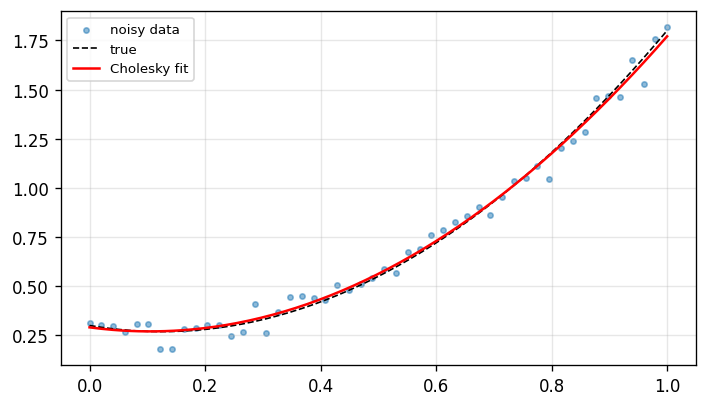

In [6]:
# fit polynomial to noised data
torch.manual_seed(42)
t = torch.linspace(0, 1, 50, dtype=torch.float64)
y_true = 2 * t**2 - 0.5 * t + 0.3
y_noisy = y_true + 0.05 * torch.randn_like(t)

# Vandermonde matrix (degree 2)
V = torch.stack([torch.ones_like(t), t, t**2], dim=1)
print(f"V shape: {V.shape} (m={V.shape[0]} > n={V.shape[1]}, overdetermined)")

# normal equations: V^T V is 3x3 SPD
G = V.T @ V
print(f"V^T V eigenvalues: {torch.linalg.eigvalsh(G).tolist()}")
print("all positive -> SPD, Cholesky works")

L = torch.linalg.cholesky(G)
rhs = V.T @ y_noisy
coeffs = torch.cholesky_solve(rhs.unsqueeze(1), L).squeeze()
print(f"\nfit: {coeffs[2]:.3f} t^2 + {coeffs[1]:.3f} t + {coeffs[0]:.3f}")
print("true: 2.000 t^2 + -0.500 t + 0.300")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(t, y_noisy, s=10, alpha=0.5, label="noisy data")
ax.plot(t, y_true, "k--", lw=1, label="true")
t_fine = torch.linspace(0, 1, 200, dtype=torch.float64)
y_fit = coeffs[0] + coeffs[1] * t_fine + coeffs[2] * t_fine**2
ax.plot(t_fine, y_fit, "r-", lw=1.5, label="Cholesky fit")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()